In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cucumber.json to cucumber (2).json


In [ ]:
import os
os.listdir()

['.config',
 'cucumber.json',
 'cucumber (2).json',
 'cucumber (1).json',
 'sample_data']

In [ ]:
import json
import pandas as pd

with open("cucumber.json") as f:
    data = json.load(f)

results = []

for feature in data:
    for scenario in feature['elements']:
        scenario_name = scenario['name']

        for step in scenario['steps']:
            status = step['result']['status']
            duration = step['result'].get('duration',0)

            results.append({
                "scenario": scenario_name,
                "status": status,
                "duration": duration
            })

df = pd.DataFrame(results)

df.head()

,scenario,status,duration
0,Listing books,passed,2570414100
1,Listing books,passed,8430440600
2,Listing books,passed,25987500
3,Verify that book list is not empty,passed,999900
4,Verify that book list is not empty,passed,377758300


In [ ]:
df["duration_seconds"] = df["duration"] / 1000000000

df.head()

,scenario,status,duration,duration_seconds
0,Listing books,passed,2570414100,2.570414
1,Listing books,passed,8430440600,8.430441
2,Listing books,passed,25987500,0.025988
3,Verify that book list is not empty,passed,999900,0.001000
4,Verify that book list is not empty,passed,377758300,0.377758


In [ ]:
scenario_results = []

for feature in data:
    for scenario in feature['elements']:
        scenario_name = scenario['name']

        statuses = [step['result']['status'] for step in scenario['steps']]

        if "failed" in statuses:
            final_status = "failed"
        else:
            final_status = "passed"

        scenario_results.append({
            "scenario": scenario_name,
            "status": final_status
        })

scenario_df = pd.DataFrame(scenario_results)

scenario_df.head()

,scenario,status
0,Listing books,passed
1,Verify that book list is not empty,passed
2,User list API performance check,passed
3,Create new user,passed
4,Generate token for user,passed


In [ ]:
scenario_df["status"].value_counts()

,count
status,
passed,35
failed,5


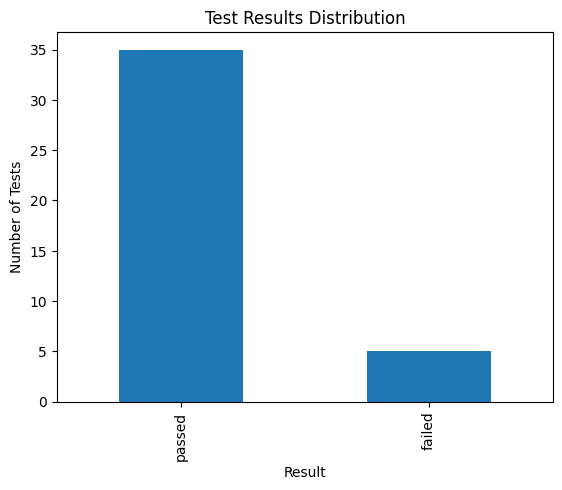

In [ ]:
import matplotlib.pyplot as plt

scenario_df["status"].value_counts().plot(kind="bar")

plt.title("Test Results Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Tests")

plt.show()

In [ ]:
total_tests = len(scenario_df)
passed_tests = (scenario_df["status"] == "passed").sum()

success_rate = (passed_tests / total_tests) * 100

print("Total Tests:", total_tests)
print("Passed Tests:", passed_tests)
print("Success Rate:", round(success_rate,2), "%")

Total Tests: 40
Passed Tests: 35
Success Rate: 87.5 %


In [ ]:
scenario_df["scenario"].value_counts()

,count
scenario,
The delete all books button is checked,2
Password is left blank,2
User list API performance check,1
Create new user,1
Listing books,1
Verify that book list is not empty,1
Add book to user,1
Generate token for user,1
All fields are successfully filled and registered.,1


In [ ]:
duration_data = []

for feature in data:
    for scenario in feature['elements']:
        scenario_name = scenario['name']

        total_duration = sum(step['result'].get('duration',0) for step in scenario['steps'])

        duration_data.append({
            "scenario": scenario_name,
            "duration_seconds": total_duration / 1000000000
        })

duration_df = pd.DataFrame(duration_data)

duration_df.head()

,scenario,duration_seconds
0,Listing books,11.026842
1,Verify that book list is not empty,3.633759
2,User list API performance check,0.436732
3,Create new user,1.861856
4,Generate token for user,1.535047


In [ ]:
duration_df.sort_values(by="duration_seconds", ascending=False).head(10)

,scenario,duration_seconds
37,The list is checked by entering an invalid cha...,96.045695
8,All fields are successfully filled and registe...,70.354614
17,Only letters (uppercase/lowercase) and numbers...,70.094732
29,Clicking the Go to Book store button,69.789395
14,Entering less than 8 characters in the passwor...,69.493284
16,The password is entered in Uppercase letters o...,69.258265
18,The password contains only numbers and special...,69.089885
15,The password is entered in lowercase letters o...,68.749812
32,The delete all books button is checked,68.639672
20,"All fields are entered correctly,",68.325848


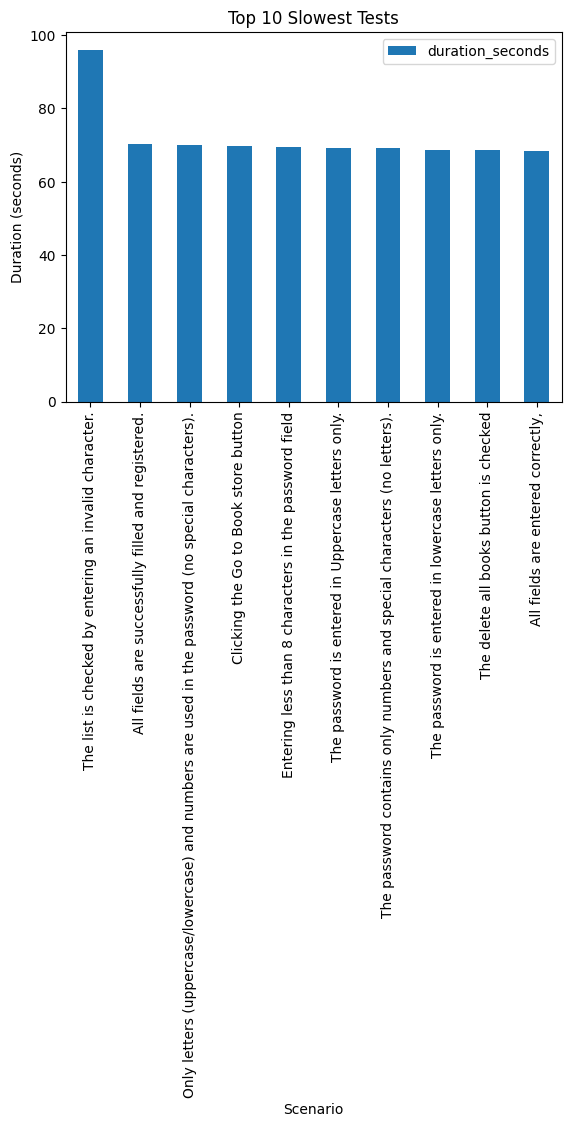

In [ ]:
duration_df.sort_values(by="duration_seconds", ascending=False).head(10).plot(
    x="scenario",
    y="duration_seconds",
    kind="bar"
)

plt.title("Top 10 Slowest Tests")
plt.ylabel("Duration (seconds)")
plt.xlabel("Scenario")

plt.show()

In [ ]:
scenario_df[scenario_df["status"] == "failed"]

,scenario,status
20,"All fields are entered correctly,",failed
28,Adjusting books per page dropdown,failed
32,The delete all books button is checked,failed
33,The delete all books button is checked,failed
37,The list is checked by entering an invalid cha...,failed


In [ ]:
failed_tests = scenario_df[scenario_df["status"] == "failed"]

print("Number of failed tests:", len(failed_tests))

Number of failed tests: 5


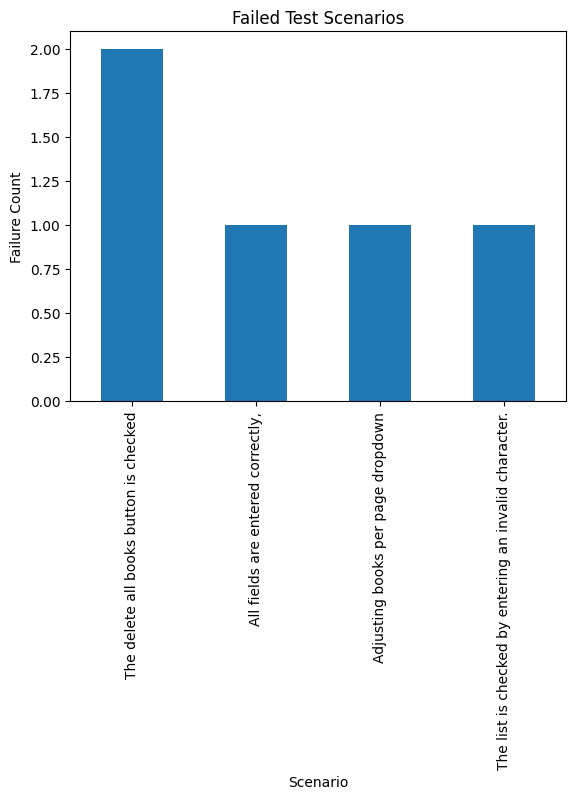

In [ ]:
failed_tests["scenario"].value_counts().plot(kind="bar")

plt.title("Failed Test Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Failure Count")

plt.show()

In [ ]:
fail_rate = (len(failed_tests) / len(scenario_df)) * 100

print("Fail Rate:", round(fail_rate,2), "%")

Fail Rate: 12.5 %


/tmp/ipykernel_27078/3556562911.py:36: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


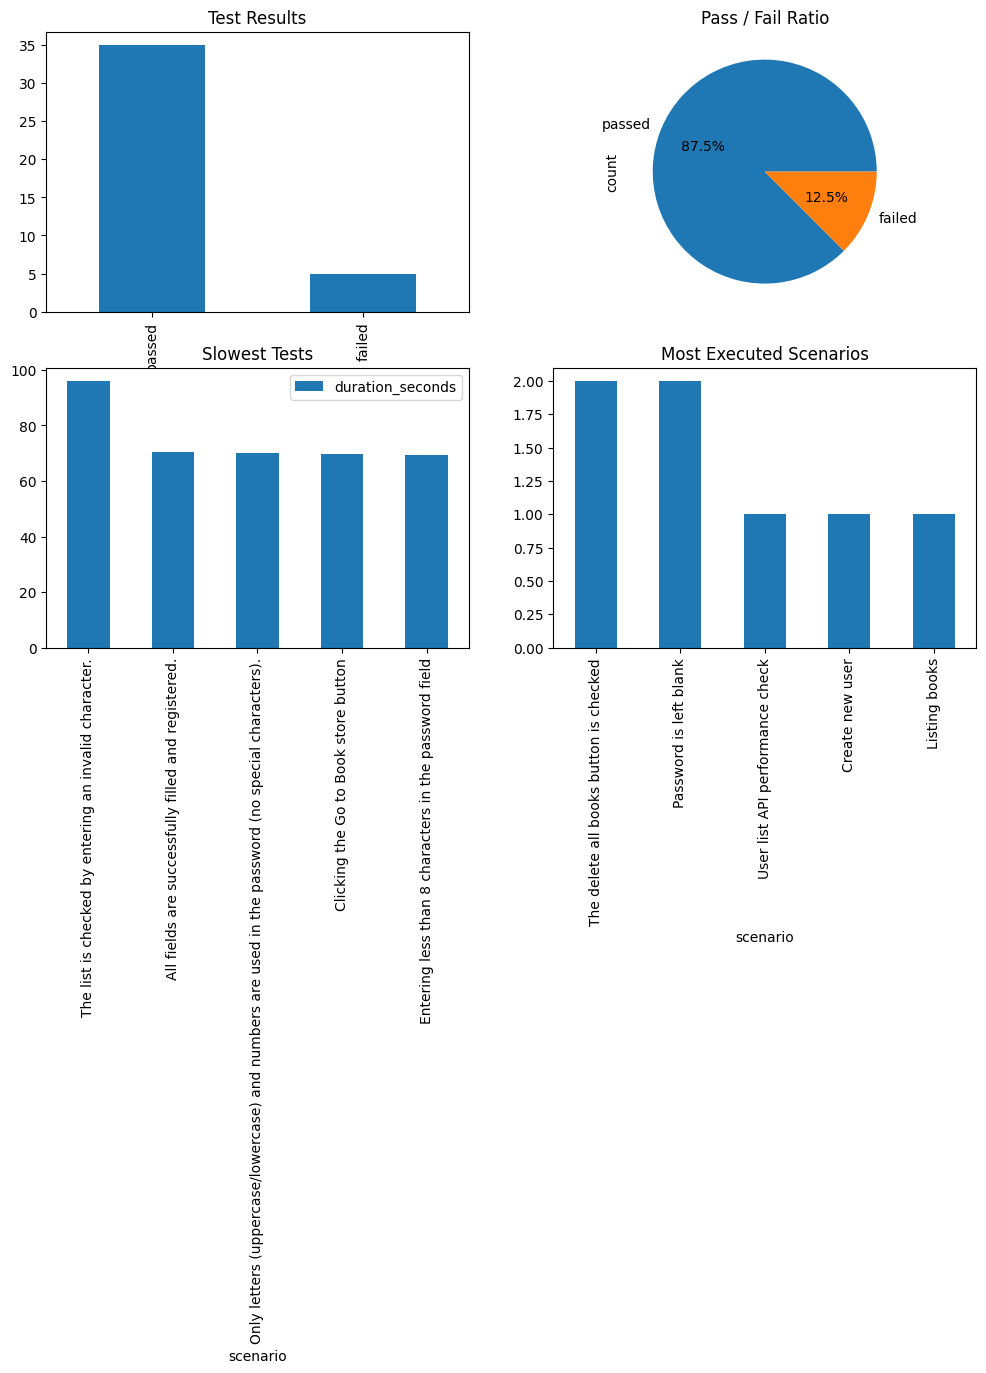

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(12,8))

# Test Result Distribution
scenario_df["status"].value_counts().plot(
    kind="bar",
    ax=axes[0,0],
    title="Test Results"
)

# Fail Rate Pie
scenario_df["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0,1],
    title="Pass / Fail Ratio"
)

# Slowest Tests
duration_df.sort_values(by="duration_seconds", ascending=False).head(5).plot(
    x="scenario",
    y="duration_seconds",
    kind="bar",
    ax=axes[1,0],
    title="Slowest Tests"
)

# Scenario Frequency
scenario_df["scenario"].value_counts().head(5).plot(
    kind="bar",
    ax=axes[1,1],
    title="Most Executed Scenarios"
)

plt.tight_layout()
plt.show()

In [ ]:
failed_tests["scenario"].value_counts()

,count
scenario,
The delete all books button is checked,2
"All fields are entered correctly,",1
Adjusting books per page dropdown,1
The list is checked by entering an invalid character.,1


In [ ]:
slow_tests = duration_df[duration_df["duration_seconds"] > duration_df["duration_seconds"].mean()]

slow_tests

,scenario,duration_seconds
8,All fields are successfully filled and registe...,70.354614
10,LastName is left blank,68.280581
11,UserName is left blank,67.772793
12,Password is left blank,68.201090
14,Entering less than 8 characters in the passwor...,69.493284
15,The password is entered in lowercase letters o...,68.749812
16,The password is entered in Uppercase letters o...,69.258265
17,Only letters (uppercase/lowercase) and numbers...,70.094732
18,The password contains only numbers and special...,69.089885
19,The password contains only letters and special...,68.015406


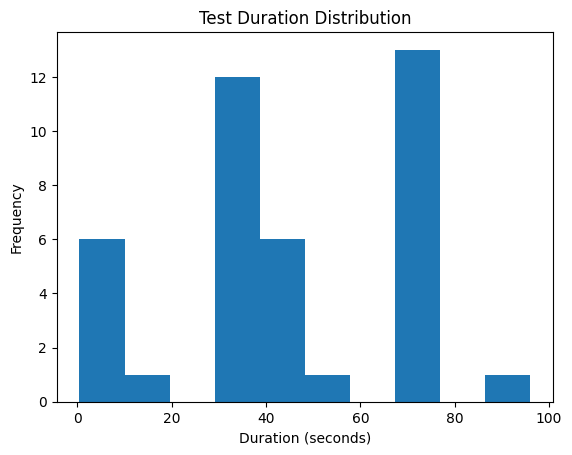

In [ ]:
duration_df["duration_seconds"].plot(kind="hist", bins=10)

plt.title("Test Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.show()

In [ ]:
merged_df = scenario_df.merge(duration_df, on="scenario")

merged_df.groupby("status")["duration_seconds"].mean()

,duration_seconds
status,
failed,62.457972
passed,41.785560


In [ ]:
types = []

for feature in data:
    for element in feature["elements"]:
        tag_list = element.get("tags", [])

        tag_names = [tag["name"] for tag in tag_list]

        if "@API" in tag_names:
            types.append("API")
        elif "@DemoQa" in tag_names:
            types.append("UI")
        else:
            types.append("Unknown")

In [ ]:
scenario_df["test_type"] = types

In [ ]:
scenario_df["test_type"].value_counts()

,count
test_type,
UI,33
API,7


In [ ]:
scenario_df.groupby("test_type")["status"].value_counts()

test_type  status
API        passed     7
UI         passed    28
           failed     5
Name: count, dtype: int64

In [ ]:
fail_analysis = scenario_df.groupby("test_type")["status"].apply(lambda x: (x=="failed").sum()/len(x)*100)

print(fail_analysis)

test_type
API     0.000000
UI     15.151515
Name: status, dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
import glob

files = glob.glob("/content/drive/MyDrive/CucumberRun/cucumber*.json")

runs = []

for i, f in enumerate(files, start=1):
    with open(f, "r", encoding="utf-8") as file:
        features = json.load(file)

        runs.append({
            "run_id": f"run_{i}",
            "features": features
        })

In [ ]:
rows = []

for run in runs:
    run_id = run["run_id"]

    for feature in run["features"]:
        if not isinstance(feature, dict):
            continue

        feature_name = feature.get("name", "unknown")

        for scenario in feature.get("elements", []):
            scenario_name = scenario.get("name", "unknown")

            for step in scenario.get("steps", []):
                rows.append({
                    "run_id": run_id,
                    "feature": feature_name,
                    "scenario": scenario_name,
                    "step": step.get("name"),
                    "status": step["result"]["status"],
                    "duration": step["result"].get("duration", 0)
                })

df = pd.DataFrame(rows)
df.head()

,run_id,feature,scenario,step,status,duration
0,run_1,BookStore API Test,Listing books,BookStore API is ready.,passed,2089715400
1,run_1,BookStore API Test,Listing books,A request is sent to receive the books.,passed,5148982000
2,run_1,BookStore API Test,Listing books,The response status code should be 200.,passed,16992200
3,run_1,BookStore API Test,Verify that book list is not empty,BookStore API is ready.,passed,1000200
4,run_1,BookStore API Test,Verify that book list is not empty,A request is sent to receive the books.,passed,364771800


In [ ]:
df.shape

(1122, 6)

In [ ]:
run_summary = df.groupby("run_id")["status"].value_counts().unstack().fillna(0)

run_summary["total"] = run_summary.sum(axis=1)
run_summary["pass_rate"] = run_summary["passed"] / run_summary["total"] * 100

run_summary

status,failed,passed,skipped,total,pass_rate
run_id,,,,,
run_1,12,341,21,374,91.176471
run_2,13,329,32,374,87.967914
run_3,5,365,4,374,97.593583


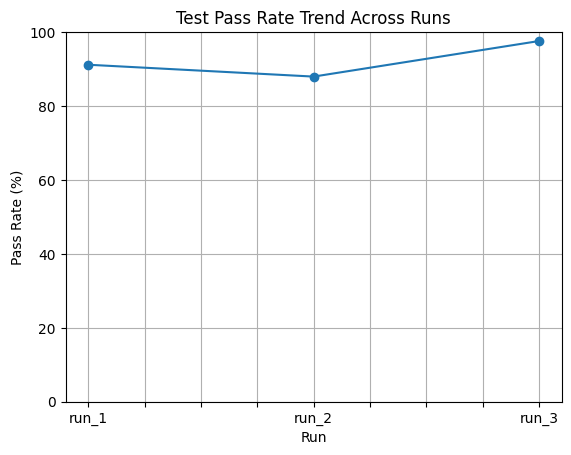

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

run_summary["pass_rate"].plot(marker="o")

plt.title("Test Pass Rate Trend Across Runs")
plt.xlabel("Run")
plt.ylabel("Pass Rate (%)")

plt.ylim(0, 100)
plt.grid()

plt.show()

In [ ]:
scenario_status = df.groupby("scenario")["status"].value_counts().unstack().fillna(0)

scenario_status["fail_rate"] = scenario_status.get("failed", 0) / scenario_status.sum(axis=1)

scenario_status.sort_values("fail_rate", ascending=False).head(100)

status,failed,passed,skipped,fail_rate
scenario,,,,
"All fields are entered correctly,",3.0,30.0,0.0,0.090909
Adjusting books per page dropdown,3.0,27.0,3.0,0.090909
The list is checked by entering an invalid character.,3.0,30.0,0.0,0.090909
Username and password are entered incorrectly.,2.0,16.0,6.0,0.083333
invalid username successful password.,2.0,16.0,6.0,0.083333
Access control to the Login tab,2.0,24.0,4.0,0.066667
The delete all books button is checked,6.0,75.0,9.0,0.066667
Check the logout button on the profile screen,2.0,24.0,4.0,0.066667
FirstName is left blank,2.0,31.0,0.0,0.060606


In [ ]:
df.groupby("run_id")["duration"].mean()

,duration
run_id,
run_1,4.918503e+09
run_2,4.732900e+09
run_3,4.722477e+09


ML MODEL

In [ ]:
ml_df = df.copy()

# label
ml_df["label"] = ml_df["status"].apply(lambda x: 1 if x == "failed" else 0)

ml_df[["step", "duration", "status", "label"]].head()

,step,duration,status,label
0,BookStore API is ready.,2089715400,passed,0
1,A request is sent to receive the books.,5148982000,passed,0
2,The response status code should be 200.,16992200,passed,0
3,BookStore API is ready.,1000200,passed,0
4,A request is sent to receive the books.,364771800,passed,0


In [ ]:
import numpy as np

ml_df["step_length"] = ml_df["step"].apply(len)
ml_df["scenario_length"] = ml_df["scenario"].apply(len)

ml_df[["step", "step_length", "scenario_length", "duration", "label"]].head()

,step,step_length,scenario_length,duration,label
0,BookStore API is ready.,23,13,2089715400,0
1,A request is sent to receive the books.,39,13,5148982000,0
2,The response status code should be 200.,39,13,16992200,0
3,BookStore API is ready.,23,34,1000200,0
4,A request is sent to receive the books.,39,34,364771800,0


In [ ]:
features = ["step_length", "scenario_length", "duration"]

X = ml_df[features]
y = ml_df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

İLK MODEL (LOGISTIC REGRESSION)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
model.score(X_test, y_test)

0.9777777777777777

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[220   0]
 [  5   0]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       220
           1       0.00      0.00      0.00         5

    accuracy                           0.98       225
   macro avg       0.49      0.50      0.49       225
weighted avg       0.96      0.98      0.97       225



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_model.feature_importances_

array([0.29456575, 0.12708541, 0.57834885])

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importance.sort_values("importance", ascending=False)

,feature,importance
2,duration,0.578349
0,step_length,0.294566
1,scenario_length,0.127085


In [ ]:
ml_df["test_type"] = ml_df["step"].apply(
    lambda x: "API" if any(word in x.lower() for word in ["request", "response", "api"]) else "UI"
)

ml_df["test_type_encoded"] = ml_df["test_type"].map({"UI": 0, "API": 1})

ml_df[["step", "test_type", "test_type_encoded"]].head(20)

,step,test_type,test_type_encoded
0,BookStore API is ready.,API,1
1,A request is sent to receive the books.,API,1
2,The response status code should be 200.,API,1
3,BookStore API is ready.,API,1
4,A request is sent to receive the books.,API,1
5,The book list should not be empty,UI,0
6,BookStore API is ready.,API,1
7,A request is sent to receive the books.,API,1
8,The response status code should be 200.,API,1
9,the response time should be less than 3 seconds.,API,1


In [ ]:
features = ["duration", "step_length", "scenario_length", "test_type_encoded"]

X = ml_df[features]
y = ml_df["label"]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9866666666666667